
# The Spatial Join Process
## Illustrated with North Wales Legacy Mining Areas & Buildings

**Goal:** Find buildings inside historic mining areas and colour them by the mining layer's 'Legend' field.

**Key Points:**
- A standard join links tables via a shared ID column.
- A spatial join uses geometry instead.

## Import Libraries and Data
### Libraries
- **geopandas** - spatial data manipulation  
- **leaflet** - visualisation

### Data
- **Mining Data** - [BGS Mining hazard (not including coal) 1 km hex grid](https://osdatahub.os.uk/data/downloads/open/GB-Hex-1km-Mining-Haz)  
- **Buildings** - [OS OpenMap - Local](https://www.ordnancesurvey.co.uk/products/os-open-map-local)

### Key Functions
- **gpd.read_file** - Used to load our data to a geodataframe.  
- **.head()** - For previewing our data prior to projecting (if necessary) and undertaking analysis.

In [12]:
# Libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data
mining = gpd.read_file(r"C:\Users\conno\Documents\Careers\Applications\UoM_Technical_GIS\Data\NWales_Mining.shp")
buildings = gpd.read_file(r"C:\Users\conno\Documents\Careers\Applications\UoM_Technical_GIS\Data\NWales_Buildings.shp")

print(f"Mining hexes : {len(mining):,}  |  Buildings: {len(buildings):,}")

Mining hexes : 406  |  Buildings: 117,395


In [13]:
mining.head()

,Legend,Class,Version,geometry
0,Localised small scale mining may have occurred...,Low,Version 8,"POLYGON ((311000 346410.161, 310000 346410.161..."
1,Localised small scale mining may have occurred...,Low,Version 8,"POLYGON ((314000 346410.161, 313000 346410.161..."
2,Localised small scale mining may have occurred...,Low,Version 8,"POLYGON ((317000 346410.161, 316000 346410.161..."
3,Localised small scale mining may have occurred...,Low,Version 8,"POLYGON ((320000 346410.161, 319000 346410.161..."
4,Underground mining is known or considered like...,Significant,Version 8,"POLYGON ((323000 346410.161, 322000 346410.161..."


In [14]:
buildings.head()

,ID,FEATCODE,geometry
0,4623912D-F439-4FA2-951F-613BC797DF99,15014,"POLYGON Z ((339353.65 376375.45 0, 339347.25 3..."
1,21E88890-E9CF-48BC-A27F-76159DDB71C3,15014,"POLYGON Z ((339365.05 376413.59 0, 339363.9 37..."
2,0CCCC7B9-5684-4587-B8D5-B5EC1777CA4B,15014,"POLYGON Z ((339355.55 376431.38 0, 339363.65 3..."
3,FE2BAFE2-CBFE-495C-ADBE-AE2C43434C0B,15014,"POLYGON Z ((339355.66 376447.95 0, 339364 3764..."
4,AE4840A7-EF50-4D32-9564-9CA5878CC685,15014,"POLYGON Z ((339369.62 376468.93 0, 339357.49 3..."


## Validate Coordinate Reference System

This is a critical step prior to analysis. Geodataframes with mismatched CRS' will likely lead to transposition errors.  

If CRS are mismatched, we can undertake a simple projection using geoPandas.

### Key Functions
**.crs** - Pull the CRS of a geodataframe.  
**.to_crs** - Project one CRS to another.

In [15]:
# We can check the CRS of our datasets using the .crs function
print(mining.crs)
print(buildings.crs)

EPSG:27700
EPSG:27700


In [16]:
if mining.crs != buildings.crs:
    print("CRS mismatch – reproject to same CRS")
    buildings = buildings.to_crs(mining.crs)
else:
    print(f"CRS match - (Mining CRS: {mining.crs}, Buildings CRS: {buildings.crs})")

CRS match - (Mining CRS: EPSG:27700, Buildings CRS: EPSG:27700)


## Spatial Join(s)

Text

### Key Functions
**gpd.sjoin** - Used to undertake the join. 

gpd.sjoin(geodataframe1 (left), geodataframe2 (right), how=, predicate=)

**how**  - two options
- "left"  = keep all left rows (null, or NaN, where no match is found)  
- "inner" = only matched rows  

**predicate** - two options
- "intersects" = any overlap counts  
- "within"     = left geodataframe feature must be fully inside right dataframe feature

**.to_file** - Saves the output.

In [17]:
# Create a new variable to store our join results
result = gpd.sjoin(buildings, mining, how="left", predicate="intersects")

matched   = result[result["index_right"].notna()] # Store our matched data
unmatched = result[result["index_right"].isna()] # Store our unmatched data - for greying out buildings not in the AOI

# Save as geopackage file
result.to_file("buildings_with_mining_info.gpkg", driver="GPKG")

## Visualisation

We will use the plotting library "matplotlib" for our generation of our maps.

In [18]:
# Setup a legend to show our different mining legacy types

## Set our mining area colours using a dictionary
LEGEND_COLOURS = {
"No known record of mining activity." : "#19ff00", # Green
"Localised small scale mining may have occurred in the area." : "#ffe900", # Yellow
"Small scale underground mining may have occurred in the area." : "#ffac00", # Orange
"Underground mining is known or considered likely to have occurred in the area." : "#ff0000", # Red
}

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

buildings.plot(
    ax=ax,
    color="blue",
    alpha=0.6
)

ax.set_title("Buildings")

plt.show()

fig.savefig("building_map.png", dpi=240)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.set_title("Mining Legacy")

mining.plot(
    ax=ax,
    color=mining["Legend"].map(LEGEND_COLOURS),
    alpha=0.8,
    edgecolor="none"
)

plt.show()

fig.savefig("mining_map.png", dpi=240)

NameError: name 'matched' is not defined

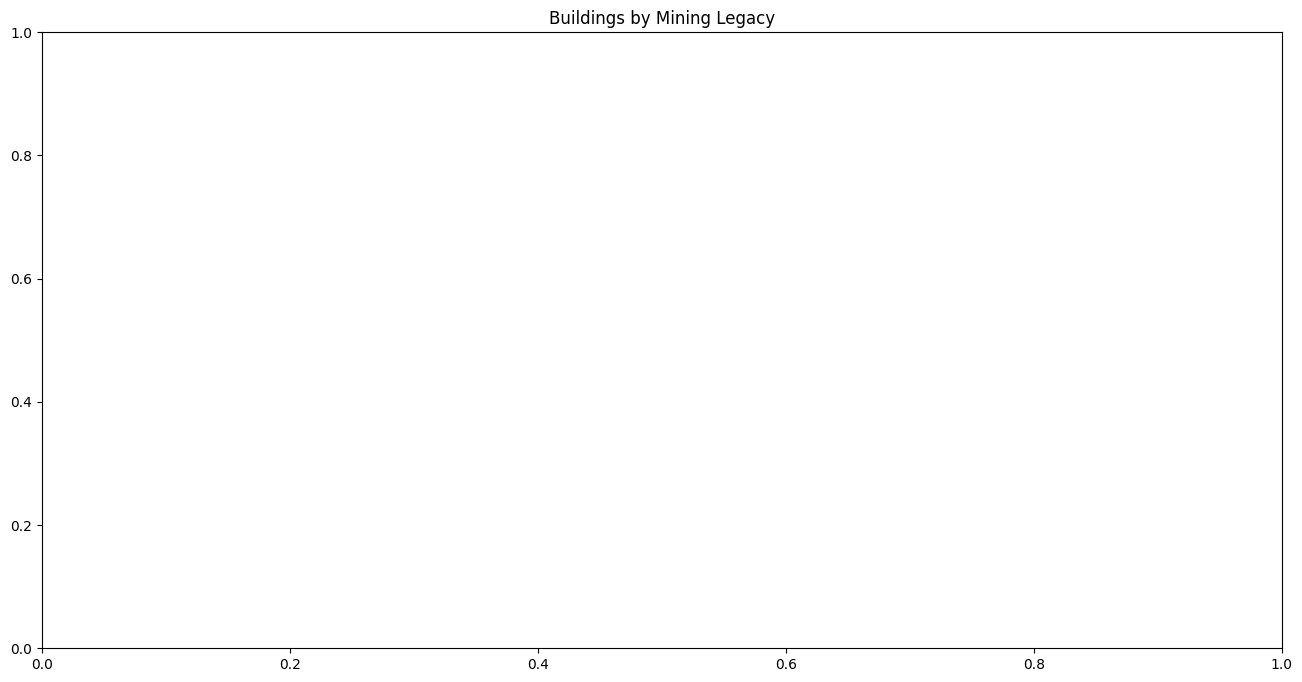

In [11]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.set_title("Buildings by Mining Legacy")

matched.plot(
    ax=ax,
    color=matched["Legend"].map(LEGEND_COLOURS),
    alpha=0.8,
    edgecolor="none"
)

plt.show()

fig.savefig("spatial_join_output_map.png", dpi=240)